# Siga o passo a passo a seguir, programando nos blocos de código as instruções contidas nos blocos de texto.

In [ ]:
# importação das bibliotecas
import numpy as np
import pandas as pd
import requests
from io import StringIO

1. Importe a base de dados de filmes que está disponível em https://drive.google.com/file/d/1wZm914T5wPwY5mj-Y3nm9650bi8eBcH5/view?usp=sharing.

In [ ]:
# copia o link do google drive (precisa ser um arquivo com permissão pública)
orig_url = 'https://drive.google.com/file/d/1wZm914T5wPwY5mj-Y3nm9650bi8eBcH5/view?usp=sharing'

# extrai o código do link do arquivo: 18Imvk9CHegElwScBGjxW2txkuzLWjMET
file_id = orig_url.split('/')[-2]

# cria um link de download do google drive
dwn_url = 'https://drive.google.com/uc?export=download&id=' + file_id

# faz o download do documento
url = requests.get(dwn_url).text

# transforma o arquivo baixado para um csv raw
csv_raw = StringIO(url)

# cria um dataframe e insere o csv nele
df = pd.read_csv(csv_raw)

In [ ]:
# visualiza os dados importados
df.head()

,Unnamed: 0,title,overview,original_language,vote_count,vote_average
0,0,Ad Astra,"The near future, a time when both hope and har...",en,"2853,0","5,9"
1,1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,"1349,0","7,2"
2,2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,"2530,0","7,1"
3,3,Ant-Man,Armed with the astonishing ability to shrink i...,en,"13611,0","7,1"
4,4,Percy Jackson: Sea of Monsters,"In their quest to confront the ultimate evil, ...",en,"3542,0","5,9"


2.  Remova todas as entradas que tiverem NaN na coluna "vote_average" e "vote_count".

In [ ]:
# verifica em qual coluna há valores vazios (NaN is True)
df.isnull().any()

Unnamed: 0           False
title                False
overview              True
original_language    False
vote_count            True
vote_average          True
dtype: bool

In [ ]:
# removemos os registros vazios em vote_count e vote_average
df.dropna(subset='vote_count', axis=0, inplace=True)
df.dropna(subset='vote_average', axis=0, inplace=True)

In [ ]:
# verifica se ainda hpa registros vazios em vote_count e vote_average
df.isnull().any()

Unnamed: 0           False
title                False
overview              True
original_language    False
vote_count           False
vote_average         False
dtype: bool

<blockquote><strong><h2>Como há valores:</h2></strong>
<ul>
    <li>vote_count (False)</li>
    <li>vote_average (False)</li>
</ul>

Portanto, não há mais valores vazios/nan nestas colunas.</blockquote>

3. Calcule a média de rating geral e liste/selecione/exiba todos os filmes que estão com "vote_average" acima dessa média.

In [ ]:
# calcula a média do vote

,Unnamed: 0,title,overview,original_language,vote_count,vote_average
0,0,Ad Astra,"The near future, a time when both hope and har...",en,"2853,0","5,9"
1,1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,"1349,0","7,2"
2,2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,"2530,0","7,1"
3,3,Ant-Man,Armed with the astonishing ability to shrink i...,en,"13611,0","7,1"
4,4,Percy Jackson: Sea of Monsters,"In their quest to confront the ultimate evil, ...",en,"3542,0","5,9"


In [ ]:
# para tirarmos a média de vote average
# devemos tratarmos o vote_average como um valor numérico.
# Observe que ele está como object/string:
df.dtypes

Unnamed: 0            int64
title                object
overview             object
original_language    object
vote_count           object
vote_average         object
dtype: object

In [ ]:
# para isso, faremos a transformação desta coluna em 'float,
# que é do tipo numérico decimal
df['vote_average'] = df['vote_average'].str.replace(',', '.').astype(float)

# e checamos a transformação dele para float
df.dtypes

Unnamed: 0             int64
title                 object
overview              object
original_language     object
vote_count            object
vote_average         float64
dtype: object

In [ ]:
# agora podemos calcular a média de vote_average
media_vote_average = df['vote_average'].mean()
media_vote_average

6.4353764157228515

In [ ]:
# agora selecionamos os filmes com o vote_average
# acima da média calculada anteriormente

busca_acima_da_media = df.query(f'vote_average > {media_vote_average}')

# OU ASSIM

busca_acima_da_media = df.query('vote_average > %s' %(media_vote_average))

# E, por fim, listamos os filmes com avaliação acima da média
busca_acima_da_media[[
    'title',
    'overview',
    'original_language',
    'vote_count',
    'vote_average'
]]

,title,overview,original_language,vote_count,vote_average
1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,"1349,0",7.2
2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,"2530,0",7.1
3,Ant-Man,Armed with the astonishing ability to shrink i...,en,"13611,0",7.1
5,Birds of Prey (and the Fantabulous Emancipatio...,"Harley Quinn joins forces with a singer, an as...",en,"2639,0",7.1
8,Underwater,After an earthquake destroys their underwater ...,en,"584,0",6.5
...,...,...,...,...,...
2997,To the Bone,A young woman dealing with anorexia meets an u...,en,"2539,0",7.3
3000,Che: Part One,"The Argentine, begins as Che and a band of Cub...",en,"418,0",6.9
3001,The Grinch,The Grinch hatches a scheme to ruin Christmas ...,en,"1577,0",6.5
3009,A Ghost Story,"Recently deceased, a white-sheeted ghost retur...",en,"1176,0",7.0


4. Gere um gráfico de barras com os cinco gêneros que mais aparecem (mesmo que um gênero para um filme seja uma lista de gêneros, considere a lista como um gênero só). O eixo y deve ser a quantidade de vezes que um gênero aparece na base de dados.

[Questão Excluída - havíamos esquecido de adicionar a coluna gênero, impossibilitando o filtro]

In [ ]:
df.head()

,Unnamed: 0,title,overview,original_language,vote_count,vote_average
0,0,Ad Astra,"The near future, a time when both hope and har...",en,"2853,0",5.9
1,1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,"1349,0",7.2
2,2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,"2530,0",7.1
3,3,Ant-Man,Armed with the astonishing ability to shrink i...,en,"13611,0",7.1
4,4,Percy Jackson: Sea of Monsters,"In their quest to confront the ultimate evil, ...",en,"3542,0",5.9


Se caso precisássemos realizar o filtro, podemos substituir como exemplo da questão 4) fazendo para a coluna de "original_language" da seguinte forma.

<Axes: >

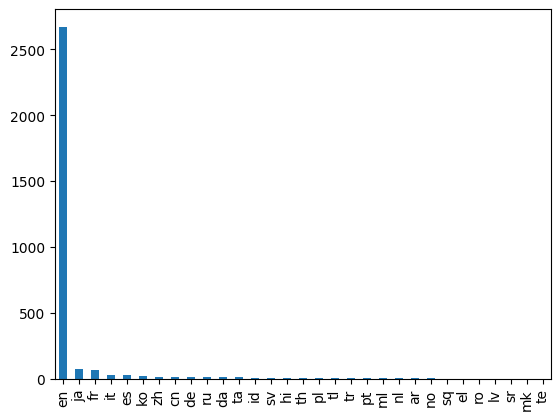

In [ ]:
df.original_language.value_counts().plot(kind='bar')